# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [60]:
# **2. Import Library**
import os

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split

# Model
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

from imblearn.over_sampling import SMOTE

# Warning
import warnings
warnings.filterwarnings('ignore')

# Setup visualization
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [61]:
#Type your code here

file_path = '../dataset/creditcard.csv'  # Update this with your actual file path
data = pd.read_csv(file_path)

display(data.head())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [62]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [63]:
display(data.describe(include='all'))

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,2.239053e-15,1.673327e-15,-1.247012e-15,8.190001e-16,1.207294e-15,4.887456e-15,1.437716e-15,-3.772171e-16,9.564149e-16,1.039917e-15,6.406204e-16,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [64]:
print(f"Missing value per column:\n{data.isnull().sum()}")
print(f"\nDuplicate rows: {data.duplicated().sum()}")

Missing value per column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Duplicate rows: 1081


In [65]:
# Cek duplicate lebih teliti
print("="*50)
print("CEK DUPLICATE ROWS")
print("="*50)

# Shape awal
print(f"Shape awal dataset: {data.shape}")

# Cek duplicate berdasarkan semua kolom
duplicate_all = data.duplicated().sum()
print(f"\nDuplicate berdasarkan SEMUA kolom: {duplicate_all}")

# Cek duplicate berdasarkan kolom tertentu (misal exclude Class)
cols_without_class = [col for col in data.columns if col != 'Class']
duplicate_no_class = data.duplicated(subset=cols_without_class).sum()
print(f"Duplicate berdasarkan semua kolom kecuali Class: {duplicate_no_class}")

# Cek duplicate berdasarkan fitur PCA saja (V1-V28)
pca_cols = [col for col in data.columns if col.startswith('V')]
duplicate_pca = data.duplicated(subset=pca_cols).sum()
print(f"Duplicate berdasarkan fitur PCA (V1-V28): {duplicate_pca}")

# Cek duplicate termasuk Amount dan Time
cols_with_amount = pca_cols + ['Amount', 'Time']
duplicate_with_amount = data.duplicated(subset=cols_with_amount).sum()
print(f"Duplicate berdasarkan PCA + Amount + Time: {duplicate_with_amount}")

# Contoh lihat duplicate values
print("\nContoh data duplicate (5 baris pertama):")
duplicate_rows = data[data.duplicated(keep='first')]
print(duplicate_rows.head())

CEK DUPLICATE ROWS
Shape awal dataset: (284807, 31)

Duplicate berdasarkan SEMUA kolom: 1081
Duplicate berdasarkan semua kolom kecuali Class: 1081
Duplicate berdasarkan fitur PCA (V1-V28): 9144
Duplicate berdasarkan PCA + Amount + Time: 1081

Contoh data duplicate (5 baris pertama):
     Time        V1        V2        V3  ...       V27       V28  Amount  Class
33   26.0 -0.529912  0.873892  1.347247  ... -0.073288  0.023307    6.14      0
35   26.0 -0.535388  0.865268  1.351076  ... -0.078306  0.025427    1.77      0
113  74.0  1.038370  0.127486  0.184456  ...  0.081247  0.001192    1.18      0
114  74.0  1.038370  0.127486  0.184456  ...  0.081247  0.001192    1.18      0
115  74.0  1.038370  0.127486  0.184456  ...  0.081247  0.001192    1.18      0

[5 rows x 31 columns]


Correlation matrix

In [66]:
correlation_with_target = data.corr()['Class'].abs().sort_values(ascending=False)
print("\nTop 10 Fitur yang Paling Berkorelasi dengan Class (Fraud):")
print(correlation_with_target[1:11])  # skip Class itself


Top 10 Fitur yang Paling Berkorelasi dengan Class (Fraud):
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
Name: Class, dtype: float64


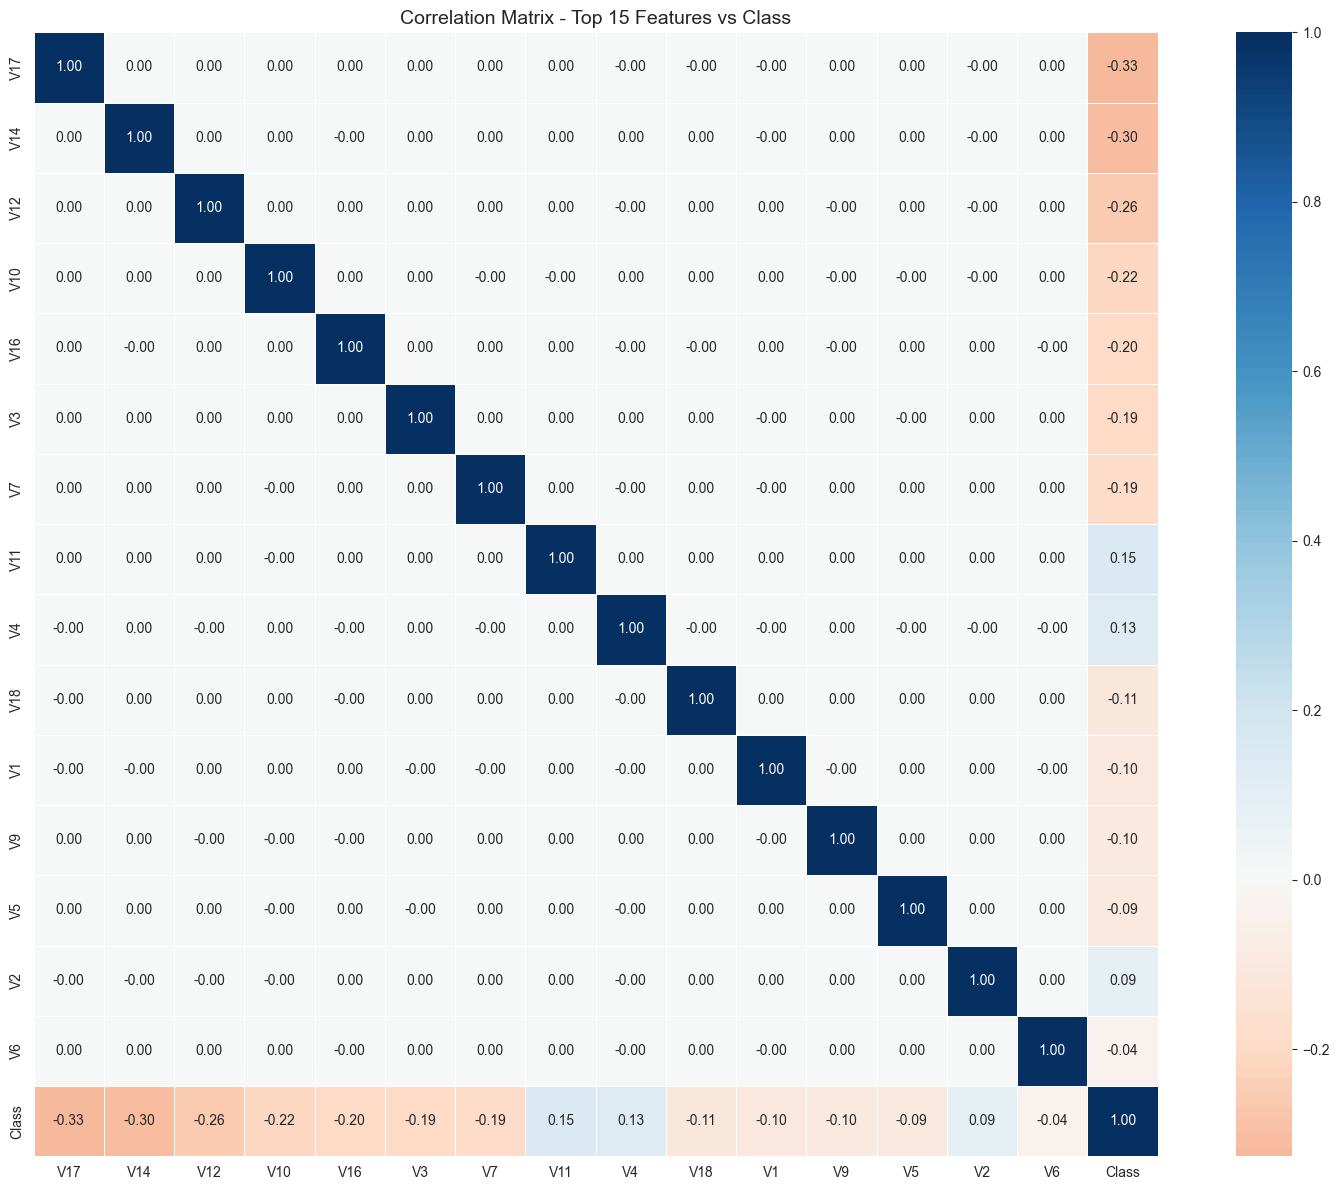

In [67]:
# Visualisasi Correlation Matrix (Heatmap)
plt.figure(figsize=(16, 12))

# Ambil top 15 fitur + Class untuk heatmap
top_features = correlation_with_target[1:16].index.tolist()
top_features.append('Class')

# Plot heatmap
sns.heatmap(data[top_features].corr(), 
            annot=True, 
            cmap='RdBu', 
            center=0,
            fmt='.2f',
            square=True,
            linewidths=0.5)
plt.title('Correlation Matrix - Top 15 Features vs Class', fontsize=14)
plt.tight_layout()
plt.show()

Jumlah fitur numerik: 30


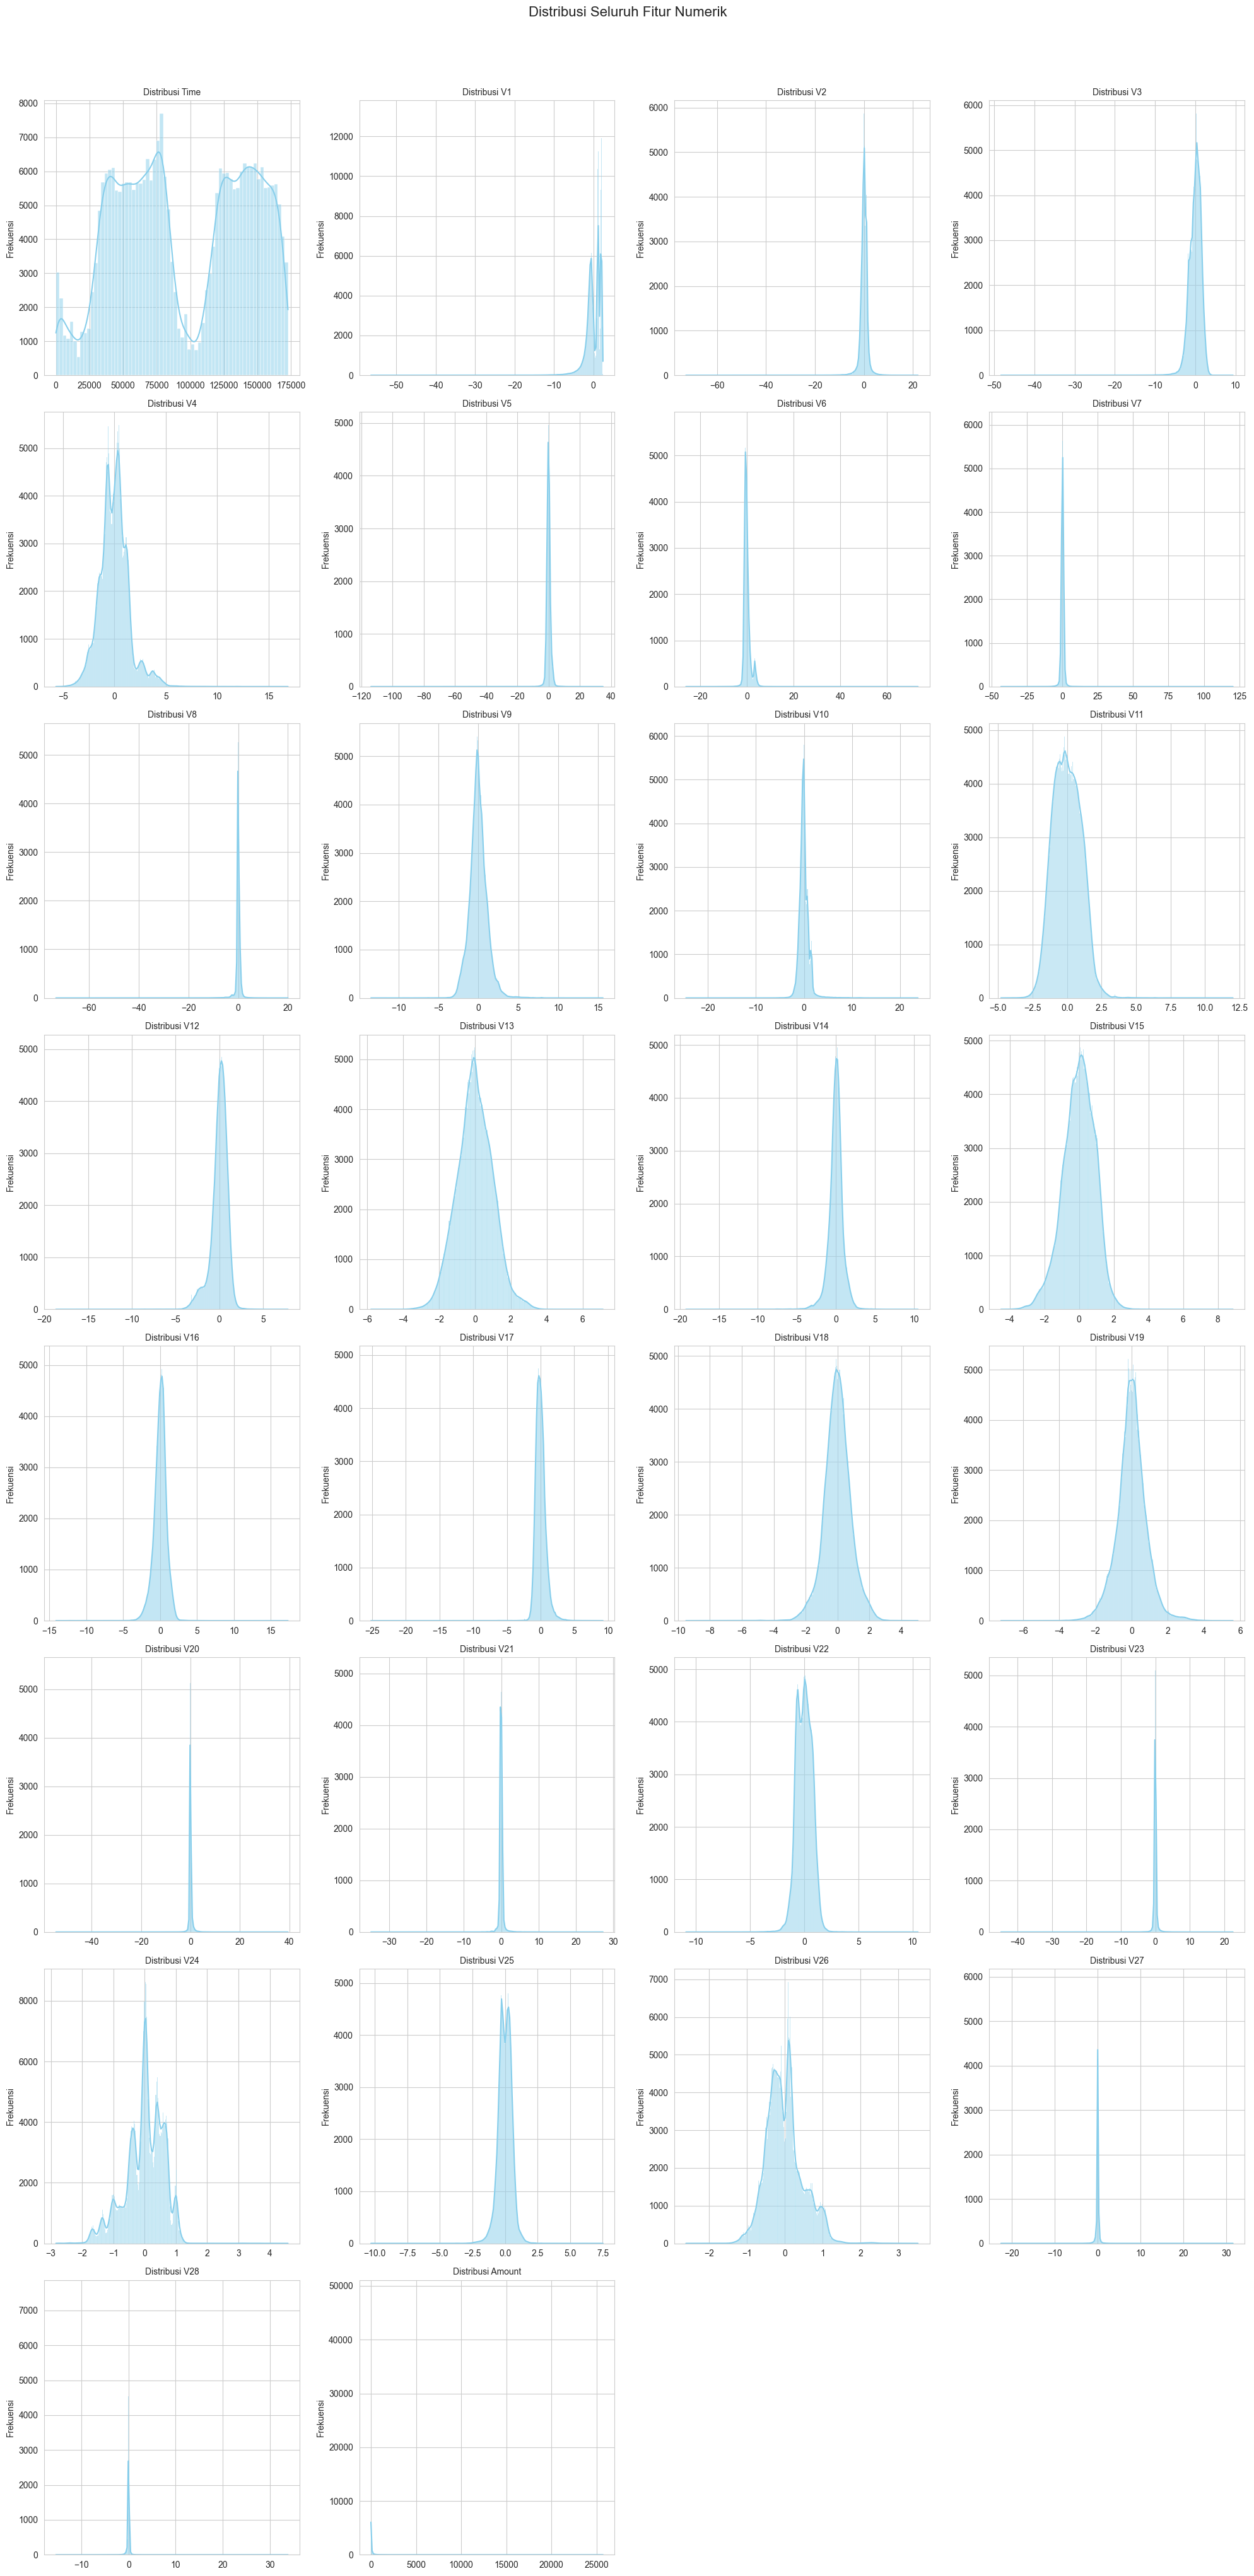

In [68]:
# Ambil semua fitur numerik except class
num_features = data.drop('Class', axis=1).columns.tolist()
print(f"Jumlah fitur numerik: {len(num_features)}")

# Setup grid
n_cols = 4 
n_rows = (len(num_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.histplot(data[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribusi {col}', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frekuensi')

# Hapus sumbu ekstra
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribusi Seluruh Fitur Numerik', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [69]:
print("PROSES REMOVE DUPLICATE ROWS")
print("="*50)
print(f"Shape awal dataset: {data.shape}")
print(f"Jumlah baris duplikat yang ditemukan: {data.duplicated().sum()}")

# HAPUS BARIS DUPLIKAT DI SINI (Menghapus 1.081 baris asli yang duplikat)
data = data.drop_duplicates(keep='first')

print(f"Shape dataset SETELAH data duplikat dihapus: {data.shape}")
print(f"Cek ulang duplikat: {data.duplicated().sum()}")

PROSES REMOVE DUPLICATE ROWS
Shape awal dataset: (284807, 31)
Jumlah baris duplikat yang ditemukan: 1081
Shape dataset SETELAH data duplikat dihapus: (283726, 31)
Cek ulang duplikat: 0


In [71]:
# **5. Data Preprocessing untuk Credit Card Fraud**

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.preprocessing import LabelEncoder
import os
import joblib

# --- 2. Menangani Data Kosong (Missing Values) ---
print(f"\n2. Missing values sebelum handling: {data.isnull().sum().sum()}")
for col in data.select_dtypes(include=['float64', 'int64']).columns:
    data[col] = data[col].fillna(data[col].median())

for col in data.select_dtypes(include=['object']).columns:
    if data[col].mode().empty:
        data[col] = data[col].fillna(0)
    else:
        data[col] = data[col].fillna(data[col].mode()[0])
print(f"   Missing values setelah handling: {data.isnull().sum().sum()}")

# --- 3. Encoding Data Kategorikal ---
print("\n3. Tidak ada kolom kategorikal yang perlu di-encoding")
le = LabelEncoder()
for col in data.select_dtypes(include=['object']).columns:
    data[col] = le.fit_transform(data[col])

# --- 4. Normalisasi/Standarisasi Fitur ---
print("\n4. Normalisasi fitur:")

# Scale Amount dengan RobustScaler
amount_scaler = RobustScaler()
data['Amount'] = amount_scaler.fit_transform(data[['Amount']])
print("   - Amount di-scale dengan RobustScaler (tahan outlier)")

# Scale fitur numerik lainnya (V1-V28) dengan StandardScaler
scaler = StandardScaler()
num_cols = data.select_dtypes(include=['float64', 'int64']).columns
# Kecuali kolom 'Class' jangan di-scale karena target
num_cols = [col for col in num_cols if col != 'Class']
data[num_cols] = scaler.fit_transform(data[num_cols])
print(f"   - {len(num_cols)} fitur numerik di-scale dengan StandardScaler")

# --- 5. Menyimpan Data Hasil Preprocessing ---
output_dir = './creditcard_preprocessing'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'creditcard_preprocessed.csv')

data.to_csv(output_path, index=False)

print(f"\n{'='*60}")
print(f"✅ PREPROCESSING SELESAI!")
print(f"{'='*60}")
print(f"📁 File saved: {output_path}")
print(f"📊 Shape akhir dataset: {data.shape}")
print(f"\n📈 Class distribution:")
print(f"   - Normal (0): {(data['Class']==0).sum():,}")
print(f"   - Fraud (1): {(data['Class']==1).sum():,}")
print(f"\n📦 Scaler disimpan di: {output_dir}")


2. Missing values sebelum handling: 0
   Missing values setelah handling: 0

3. Tidak ada kolom kategorikal yang perlu di-encoding

4. Normalisasi fitur:
   - Amount di-scale dengan RobustScaler (tahan outlier)
   - 30 fitur numerik di-scale dengan StandardScaler

✅ PREPROCESSING SELESAI!
📁 File saved: ./creditcard_preprocessing\creditcard_preprocessed.csv
📊 Shape akhir dataset: (283726, 31)

📈 Class distribution:
   - Normal (0): 283,253
   - Fraud (1): 473

📦 Scaler disimpan di: ./creditcard_preprocessing
